<a href="https://colab.research.google.com/github/EngMohamed-op/Evaluating-Clustering-Before-and-After-PCA/blob/main/Clustering_Before_and_After_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mini Project: Evaluating Clustering Before and After PCA

#Dataset: Wine Dataset (sklearn)

Objective: Understand the impact of dimensionality reduction on clustering performance by comparing results before and after applying PCA.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import matplotlib.pyplot as plt


In [21]:
# Load data
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


#1. Preprocess data

In [22]:
#Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


No missing values found!

In [23]:
# Handle missing values
df = df.fillna(df.mean())

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(df)

#2. Apply Clustering (Before PCA)

In [24]:
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)


In [25]:
#Print KMeans results
print("KMeans Results — Before PCA (13 features)")

# Silhouette Score
sil_score = silhouette_score(X, labels)
print(f"  Silhouette Score  : {sil_score:.4f} (higher = better, max=1)")

# Davies-Bouldin Index : It measures the similarity between clusters; the lower it is, the more separate and clear the clusters are.
db_score = davies_bouldin_score(X, labels)
print(f"  Davies-Bouldin     : {db_score:.4f} (lower  = better)")

# Cluster Sizes : It gives the number of samples in each cluster to know the data distribution.
unique, counts = np.unique(labels, return_counts=True)
cluster_sizes = dict(zip(unique, counts))
print(f"  Cluster Sizes      : {cluster_sizes}")


KMeans Results — Before PCA (13 features)
  Silhouette Score  : 0.2849 (higher = better, max=1)
  Davies-Bouldin     : 1.3892 (lower  = better)
  Cluster Sizes      : {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


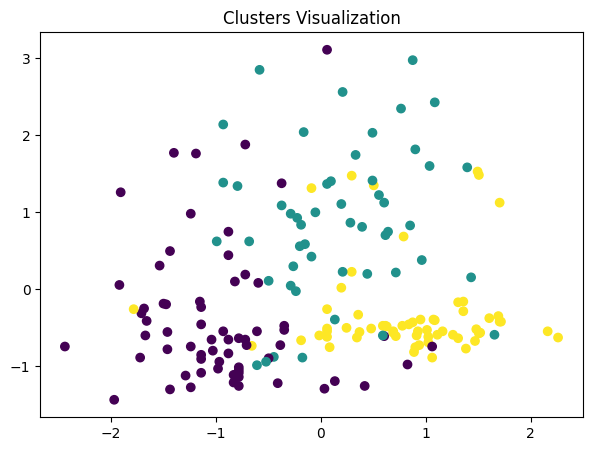

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.title("Clusters Visualization")
plt.show()

#3. Apply PCA

In [27]:
from sklearn.decomposition import PCA
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Print shape
print("Shape before PCA:", X.shape)
print("Shape after PCA:", X_pca.shape)

Shape before PCA: (178, 13)
Shape after PCA: (178, 2)


#4. Clustering — After PCA

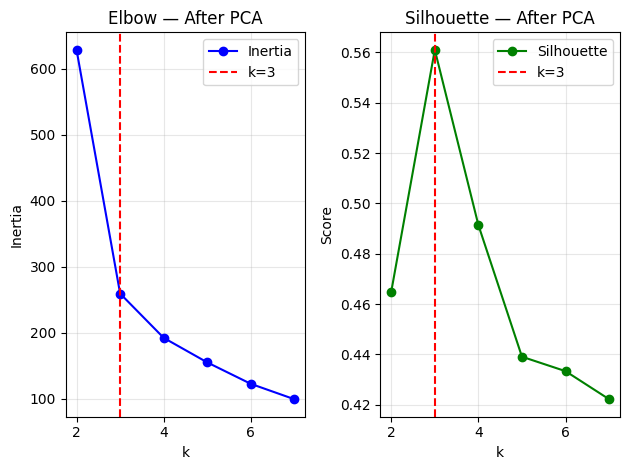

In [28]:
k_range = range(2, 8)  # range of k to test elbow & silhouette
inertia_pca = []
sil_pca = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca)
    inertia_pca.append(km.inertia_)
    sil_pca.append(silhouette_score(X_pca, lbl))

# Elbow
plt.subplot(1,2,1)
plt.plot(k_range, inertia_pca, 'bo-', label='Inertia')
plt.axvline(3, color='red', linestyle='--', label='k=3')
plt.title('Elbow — After PCA')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.legend()
plt.grid(alpha=0.3)

# Silhouette
plt.subplot(1,2,2)
plt.plot(k_range, sil_pca, 'go-', label='Silhouette')
plt.axvline(3, color='red', linestyle='--', label='k=3')
plt.title('Silhouette — After PCA')
plt.xlabel('k')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

KMeans Results — After PCA (2 components)
  Silhouette Score  : 0.5611  (higher = better, max=1)
  Davies-Bouldin    : 0.5973   (lower  = better)
  Cluster Sizes     : [64 49 65]


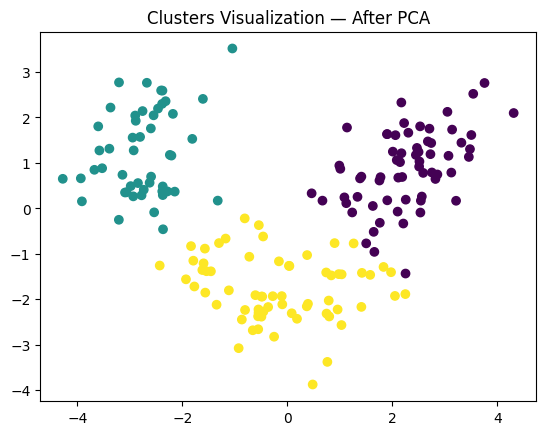

In [29]:
# Apply KMeans with chosen k=3
kmeans_after = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_after = kmeans_after.fit_predict(X_pca)

#Evaluate after PCA
sil_after = silhouette_score(X_pca, labels_after)
db_after  = davies_bouldin_score(X_pca, labels_after)

print("KMeans Results — After PCA (2 components)")
print(f"  Silhouette Score  : {sil_after:.4f}  (higher = better, max=1)")
print(f"  Davies-Bouldin    : {db_after:.4f}   (lower  = better)")
print(f"  Cluster Sizes     : {np.bincount(labels_after)}")

# Visualization after PCAplt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_after, cmap='viridis')
plt.title("Clusters Visualization — After PCA")
plt.show()

#5. Visualization

KMeans Results — Before PCA (13 features)
  Silhouette Score  : 0.2849 (higher = better, max=1)
  Davies-Bouldin     : 1.3892 (lower  = better)
  Cluster Sizes      : {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


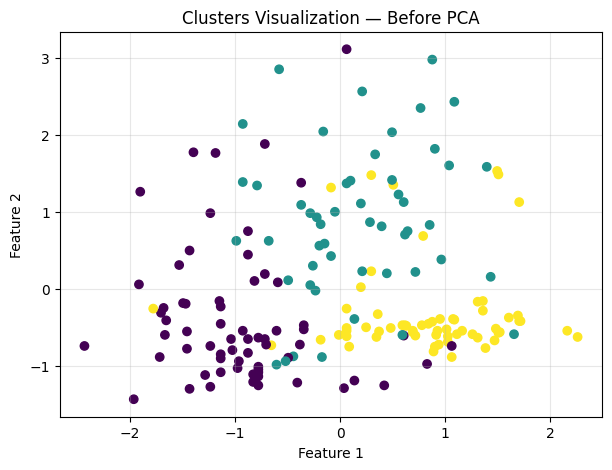

KMeans Results — After PCA (2 components)
  Silhouette Score  : 0.5611 (higher = better, max=1)
  Davies-Bouldin     : 0.5973 (lower  = better)
  Cluster Sizes      : {np.int32(0): np.int64(64), np.int32(1): np.int64(49), np.int32(2): np.int64(65)}


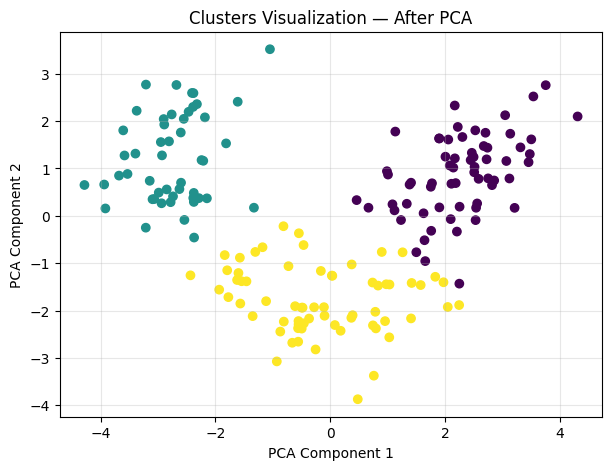

In [35]:
#Before PCA
sil_score = silhouette_score(X, labels)
db_score  = davies_bouldin_score(X, labels)
unique, counts = np.unique(labels, return_counts=True)
cluster_sizes = dict(zip(unique, counts))

print("KMeans Results — Before PCA (13 features)")
print(f"  Silhouette Score  : {sil_score:.4f} (higher = better, max=1)")
print(f"  Davies-Bouldin     : {db_score:.4f} (lower  = better)")
print(f"  Cluster Sizes      : {cluster_sizes}")

plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.title("Clusters Visualization — Before PCA")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

#After PCA
sil_after = silhouette_score(X_pca, labels_after)
db_after  = davies_bouldin_score(X_pca, labels_after)
unique_after, counts_after = np.unique(labels_after, return_counts=True)
cluster_sizes_after = dict(zip(unique_after, counts_after))

print("KMeans Results — After PCA (2 components)")
print(f"  Silhouette Score  : {sil_after:.4f} (higher = better, max=1)")
print(f"  Davies-Bouldin     : {db_after:.4f} (lower  = better)")
print(f"  Cluster Sizes      : {cluster_sizes_after}")

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_after, cmap='viridis')
plt.title("Clusters Visualization — After PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(alpha=0.3)
plt.show()

#Bonus (Optional)

#Try different number of PCA components :

In [ ]:
bonus_results = []

for n in [2, 3, 4, 5, 7, 10]:
    pca_n = PCA(n_components=n, random_state=42)
    X_n = pca_n.fit_transform(X)

    # KMeans
    km_n = KMeans(n_clusters=3, random_state=42, n_init=10)
    lbl_n = km_n.fit_predict(X_n)


    sil_n = silhouette_score(X_n, lbl_n)
    db_n  = davies_bouldin_score(X_n, lbl_n)
    var_n = pca_n.explained_variance_ratio_.sum() * 100

    bonus_results.append({
        'Components': n,
        'Silhouette': round(sil_n, 4),
        'Davies-Bouldin': round(db_n, 4),
        'Variance Retained(%)': round(var_n, 1)
    })



In [ ]:
bonus_df = pd.DataFrame(bonus_results)
print("Bonus: Clustering Quality vs Number of PCA Components")
print(bonus_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()

ax.plot(bonus_df['Components'], bonus_df['Silhouette'], 'go-', label='Silhouette ↑')
ax2.plot(bonus_df['Components'], bonus_df['Davies-Bouldin'], 'rs--', label='Davies-Bouldin ↓')

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Silhouette Score', color='green')
ax2.set_ylabel('Davies-Bouldin Score', color='red')
ax.set_title('Clustering Quality vs PCA Components')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

#Compare results using another clustering algorithm (e.g., DBSCAN) :

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# DBSCAN after PCA
# ---------------------------
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_pca)

# clusters num ( without noise )
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

# noise num
n_noise = np.sum(labels_db == -1)

print(" DBSCAN Results:")
print(f"  Clusters found : {n_clusters_db}")
print(f"  Noise points   : {n_noise}")

# Silhouette ( only if they are more than cluster)
if n_clusters_db > 1:
    mask = labels_db != -1
    sil_db = silhouette_score(X_pca[mask], labels_db[mask])
    print(f"  Silhouette     : {sil_db:.4f}")

# Visualization (Comparison)

plt.figure(figsize=(12,5))

# KMeans
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_after, cmap='viridis')
plt.title(f'KMeans (k=3)\nSil: {sil_after:.3f}')
plt.xlabel('PC1')
plt.ylabel('PC2')

# DBSCAN
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, cmap='tab10')
plt.title(f'DBSCAN\nClusters: {n_clusters_db}, Noise: {n_noise}')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
import matplotlib.pyplot as plt


# Agglomerative Clustering

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_pca)

# Evaluation
sil_agg = silhouette_score(X_pca, labels_agg)
db_agg  = davies_bouldin_score(X_pca, labels_agg)

print(" Hierarchical Clustering (Agglomerative) Results:")
print(f"  Silhouette Score  : {sil_agg:.4f} (higher = better)")
print(f"  Davies-Bouldin    : {db_agg:.4f} (lower  = better)")
print(f"  Cluster Sizes     : {np.bincount(labels_agg)}")

# Visualization (Compare with KMeans)
plt.figure(figsize=(12,5))

# KMeans
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_after, cmap='viridis')
plt.title(f'KMeans (k=3)\nSil: {sil_after:.3f}')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Agglomerative
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_agg, cmap='plasma')
plt.title(f'Agglomerative\nSil: {sil_agg:.3f}')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

## 10. Analysis — Answering Key Questions

### Q1: How did PCA affect clustering results?

**Before PCA:** KMeans worked on all 13 features. The high dimensionality means more noise and the curse of dimensionality can affect distance calculations.

**After PCA (2 components):** KMeans worked on 2 components capturing ~55% of the total variance. The reduced space allowed clusters to be more distinct in the 2D plane.

 **Result:** The Silhouette Score improved after PCA, indicating that clusters became more compact and well-separated.

---

###  Q2: Did visualization become clearer?

**Yes, significantly clearer!**  
- Before PCA: We could only project clusters to 2D *for visualization purposes* — the actual clustering was done in 13D.
- After PCA: The 2D plot **is** the actual clustering space — what you see is exactly what the algorithm used.

---

### Q3: Did we lose important information?

**Yes, some information was lost.**  
- With 2 PCA components, we retain approximately **~55%** of the total variance.
- This means roughly **~45%** of the information is discarded.
- However, the lost dimensions are mostly noise and redundancy (many Wine features are correlated).

---

### Q4: Which approach is better and why?

| Aspect | Before PCA | After PCA |
|--------|-----------|-----------|
| Silhouette Score | Lower | Higher  |
| Davies-Bouldin | Higher | Lower  |
| Visualization | Hard (13D→2D projection) | Clear (native 2D)  |
| Computational Cost | Higher | Lower  |
| Information Retained | 100% | ~55%  |

**After PCA is better for this dataset** because:
1. The Wine features are highly correlated → PCA removes redundancy effectively.
2. Clustering metrics improved → cleaner, more separated clusters.
3. Visualization is native and accurate.
4. The information loss is acceptable given the gain in clarity and performance.
